## The class Perceptron

The class Perceptron implements a single\-layer perceptron with $n$ inputs. This class provides the following public functions: 

- predict\(inputs\) calculates the weighted sum of the inputs and applies the step function to calculate the output.

- fit\(inputs, labels, learning\_rate, epochs\) fits the model by updating the weights and the bias considering the learning rate and the error of the prediction. The training inputs define the input patterns and the labels define the expected outputs, the training is run up to the given epochs \(iterations\).

- predictions\(inputs, labels\) returns a list with the model predictions.

- evaluate\(input, labels, function\) evaluates the accuracy of the model.

The perceptron is a linear classifier and can "learn" linearly separable functions.



In [1]:
import random
import numpy as np

class Perceptron:
    def __init__(self, total_inputs):
        # the weights and the bias are initialized to zeros

        self.__weights = np.zeros(total_inputs)
        self.__bias = 0

    def __step(self, x):
        # the activation function is a step function: 1 if x > 0 and 0 otherwise

        return 1 if x > 0 else 0

    @property
    def weights(self):
        return self.__weights

    @property
    def bias(self):
        return self.__bias

    def predict(self, inputs):
        # the prediction is calculated as the dot product of the weights and the inputs plus the bias

        activation = np.dot(self.__weights.T, np.array(inputs)) + self.__bias

        return self.__step(activation)

    def fit(self, inputs, labels, learning_rate, epochs):
        # the perceptron is trained by trial and error, adjusting the weights and the bias at each iteration (epoch)

        for epoch in range(epochs):
            for input, label in zip(np.array(inputs), np.array(labels)):
                prediction = self.predict(input)

                # update the weights and the bias considering the learning rate and the error of the prediction (label - prediction)

                self.__weights = self.__weights + learning_rate * (label - prediction) * input
                self.__bias = self.__bias + learning_rate * (label - prediction)

    def predictions(self, inputs, labels):
        output = []

        for input, label in zip(inputs, labels):
            output.append(self.predict(input))

        return output

    def evaluate(self, inputs, labels, title):
        print (f"{title} \n")

        correct_predictions = 0

        for input, label in zip(inputs, labels):
            prediction = self.predict(input)

            if prediction == label:
                correct_predictions+=1

                print (f"{input} {prediction}")
            else:
                print (f"{input} {prediction} is not correct, it must be {label}")

        print (f"\nAccuracy {(correct_predictions/len(inputs)) * 100}%\n")

In [2]:
print("2-input logic functions learned by a single-layer perceptron using 100% of the inputs \n")

# 2-input logic functions OR, NOR, AND, NAND, Least Significant Bit, Most Significant Bit, and XOR

MAX_EPOCHS = 10

inputs = [[0, 0], [0, 1], [1, 0], [1, 1]]

# OR

or_perceptron = Perceptron(total_inputs=2)
or_perceptron.fit([[0, 0], [0, 1], [1, 0], [1, 1]], [0, 1, 1, 1], learning_rate=0.1, epochs=MAX_EPOCHS)
or_perceptron.evaluate([[0, 0], [0, 1], [1, 0], [1, 1]], [0, 1, 1, 1],"2-input OR")

# NOR

nor_perceptron = Perceptron(total_inputs=2)
nor_perceptron.fit([[0, 0], [0, 1], [1, 0], [1, 1]], [1, 0, 0, 0], learning_rate=0.1, epochs=MAX_EPOCHS)
nor_perceptron.evaluate([[0, 0], [0, 1], [1, 0], [1, 1]], [1, 0, 0, 0], "2-input NOR")

# AND

and_perceptron = Perceptron(total_inputs=2)
and_perceptron.fit([[0, 0], [0, 1], [1, 0], [1, 1]], [0, 0, 0, 1], learning_rate=0.1, epochs=MAX_EPOCHS)
and_perceptron.evaluate([[0, 0], [0, 1], [1, 0], [1, 1]], [0, 0, 0, 1], "2-input AND")

# NAND

nand_perceptron = Perceptron(total_inputs=2)
nand_perceptron.fit([[0, 0], [0, 1], [1, 0], [1, 1]], [1, 1, 1, 0], learning_rate=0.1, epochs=MAX_EPOCHS)
nand_perceptron.evaluate([[0, 0], [0, 1], [1, 0], [1, 1]], [1, 1, 1, 0], "2-input NAND")

# Least Significant Bit (lsb)

lsb_perceptron = Perceptron(total_inputs=2)
lsb_perceptron.fit([[0, 0], [0, 1], [1, 0], [1, 1]], [0, 1, 0, 1], learning_rate=0.1, epochs=MAX_EPOCHS)
lsb_perceptron.evaluate([[0, 0], [0, 1], [1, 0], [1, 1]], [0, 1, 0, 1], "2-input Least Significant Bit")

# Most Significant Bit (msb)

msb_perceptron = Perceptron(total_inputs=2)
msb_perceptron.fit([[0, 0], [0, 1], [1, 0], [1, 1]], [0, 0, 1, 1], learning_rate=0.1, epochs=MAX_EPOCHS)
msb_perceptron.evaluate([[0, 0], [0, 1], [1, 0], [1, 1]], [0, 0, 1, 1], "2-input Most Significant Bit")

# Most Significant Bit or Least Significant Bit (msb OR lsb)

msb_lsb_perceptron = Perceptron(total_inputs=2)
msb_lsb_perceptron.fit([[0, 0], [0, 1], [1, 0], [1, 1]], [0, 1, 1, 1], learning_rate=0.1, epochs=MAX_EPOCHS)
msb_lsb_perceptron.evaluate([[0, 0], [0, 1], [1, 0], [1, 1]], [0, 1, 1, 1], "2-input Most Significant Bit or Least Significant Bit")

# Can the Perceptron learn the XOR function? No, the XOR function is non-linearly separable

xor_perceptron = Perceptron(total_inputs=2)
xor_perceptron.fit([[0, 0], [0, 1], [1, 0], [1, 1]], [0, 1, 1, 0], learning_rate=0.1, epochs=MAX_EPOCHS)
xor_perceptron.evaluate([[0, 0], [0, 1], [1, 0], [1, 1]], [0, 1, 1, 0], "2-input XOR")

2-input logic functions learned by a single-layer perceptron using 100% of the inputs 

2-input OR 

[0, 0] 0
[0, 1] 1
[1, 0] 1
[1, 1] 1

Accuracy 100.0%

2-input NOR 

[0, 0] 1
[0, 1] 0
[1, 0] 0
[1, 1] 0

Accuracy 100.0%

2-input AND 

[0, 0] 0
[0, 1] 0
[1, 0] 0
[1, 1] 1

Accuracy 100.0%

2-input NAND 

[0, 0] 1
[0, 1] 1
[1, 0] 1
[1, 1] 0

Accuracy 100.0%

2-input Least Significant Bit 

[0, 0] 0
[0, 1] 1
[1, 0] 0
[1, 1] 1

Accuracy 100.0%

2-input Most Significant Bit 

[0, 0] 0
[0, 1] 0
[1, 0] 1
[1, 1] 1

Accuracy 100.0%

2-input Most Significant Bit or Least Significant Bit 

[0, 0] 0
[0, 1] 1
[1, 0] 1
[1, 1] 1

Accuracy 100.0%

2-input XOR 

[0, 0] 1 is not correct, it must be 0
[0, 1] 1
[1, 0] 0 is not correct, it must be 1
[1, 1] 0

Accuracy 50.0%



In [3]:
print("3-input logic functions learned by a single-layer perceptron using 100% of the inputs \n")

# 3-input logic functions OR, NOR, AND, NAND, Least Significant Bit, Most Significant Bit, and XOR

MAX_EPOCHS = 10

inputs = [[0, 0, 0], [0, 0, 1], [0, 1, 0], [0, 1, 1], [1, 0, 0], [1, 0, 1], [1, 1, 0], [1, 1, 1]]

# OR

or_perceptron = Perceptron(total_inputs=3)
or_perceptron.fit(inputs, [0, 1, 1, 1, 1, 1, 1, 1], learning_rate=0.1, epochs=MAX_EPOCHS)
or_perceptron.evaluate(inputs, [0, 1, 1, 1, 1, 1, 1, 1], "3-input OR")

# NOR

nor_perceptron = Perceptron(total_inputs=3)
nor_perceptron.fit(inputs, [1, 0, 0, 0, 0, 0, 0, 0], learning_rate=0.1, epochs=MAX_EPOCHS)
nor_perceptron.evaluate(inputs, [1, 0, 0, 0, 0, 0, 0, 0], "3-input NOR")

# AND

and_perceptron = Perceptron(total_inputs=3)
and_perceptron.fit(inputs, [0, 0, 0, 0, 0, 0, 0, 1], learning_rate=0.1, epochs=MAX_EPOCHS)
and_perceptron.evaluate(inputs, [0, 0, 0, 0, 0, 0, 0, 1], "3-input AND")

# NAND

nand_perceptron = Perceptron(total_inputs=3)
nand_perceptron.fit(inputs, [1, 1, 1, 1, 1, 1, 1, 0], learning_rate=0.1, epochs=MAX_EPOCHS)
nand_perceptron.evaluate(inputs, [1, 1, 1, 1, 1, 1, 1, 0], "3-input NAND")

# Least Significant Bit (lsb)

lsb_perceptron = Perceptron(total_inputs=3)
lsb_perceptron.fit(inputs, [0, 1, 0, 1, 0, 1, 0, 1], learning_rate=0.1, epochs=MAX_EPOCHS)
lsb_perceptron.evaluate(inputs, [0, 1, 0, 1, 0, 1, 0, 1], "3-input Least Significant Bit")

# Most Significant Bit (msb)

msb_perceptron = Perceptron(total_inputs=3)
msb_perceptron.fit(inputs, [0, 0, 0, 0, 1, 1, 1, 1], learning_rate=0.1, epochs=MAX_EPOCHS)
msb_perceptron.evaluate(inputs, [0, 0, 0, 0, 1, 1, 1, 1], "3-input Most Significant Bit")

# Most Significant Bit or Least Significant Bit (msb OR lsb)

msb_lsb_perceptron = Perceptron(total_inputs=3)
msb_lsb_perceptron.fit(inputs, [0, 1, 0, 1, 1, 1, 1, 1], learning_rate=0.1, epochs=MAX_EPOCHS)
msb_lsb_perceptron.evaluate(inputs, [0, 1, 0, 1, 1, 1, 1, 1], "3-input Most Significant Bit or Least Significant Bit")

# Can the Perceptron learn the XOR function? No, the XOR function is non-linearly separable

xor_perceptron = Perceptron(total_inputs=3)
xor_perceptron.fit(inputs, [0, 1, 1, 0, 1, 0, 0, 1], learning_rate=0.1, epochs=MAX_EPOCHS)
xor_perceptron.evaluate(inputs, [0, 1, 1, 0, 1, 0, 0, 1], "3-input XOR")

3-input logic functions learned by a single-layer perceptron using 100% of the inputs 

3-input OR 

[0, 0, 0] 0
[0, 0, 1] 1
[0, 1, 0] 1
[0, 1, 1] 1
[1, 0, 0] 1
[1, 0, 1] 1
[1, 1, 0] 1
[1, 1, 1] 1

Accuracy 100.0%

3-input NOR 

[0, 0, 0] 1
[0, 0, 1] 0
[0, 1, 0] 0
[0, 1, 1] 0
[1, 0, 0] 0
[1, 0, 1] 0
[1, 1, 0] 0
[1, 1, 1] 0

Accuracy 100.0%

3-input AND 

[0, 0, 0] 0
[0, 0, 1] 0
[0, 1, 0] 0
[0, 1, 1] 0
[1, 0, 0] 0
[1, 0, 1] 0
[1, 1, 0] 0
[1, 1, 1] 1

Accuracy 100.0%

3-input NAND 

[0, 0, 0] 1
[0, 0, 1] 1
[0, 1, 0] 1
[0, 1, 1] 1
[1, 0, 0] 1
[1, 0, 1] 1
[1, 1, 0] 1
[1, 1, 1] 0

Accuracy 100.0%

3-input Least Significant Bit 

[0, 0, 0] 0
[0, 0, 1] 1
[0, 1, 0] 0
[0, 1, 1] 1
[1, 0, 0] 0
[1, 0, 1] 1
[1, 1, 0] 0
[1, 1, 1] 1

Accuracy 100.0%

3-input Most Significant Bit 

[0, 0, 0] 0
[0, 0, 1] 0
[0, 1, 0] 0
[0, 1, 1] 0
[1, 0, 0] 1
[1, 0, 1] 1
[1, 1, 0] 1
[1, 1, 1] 1

Accuracy 100.0%

3-input Most Significant Bit or Least Significant Bit 

[0, 0, 0] 0
[0, 0, 1] 1
[0, 1, 0] 0
[0, 1, 1] 1
[1, 0

In [4]:
print("Linearly separable function Majority learned by a single-layer perceptron using 100% of the inputs \n")

# 5-input majority function

MAX_EPOCHS = 20

inputs = [[0, 0, 0, 0, 0],
          [0, 0, 0, 0, 1],
          [0, 0, 0, 1, 0],
          [0, 0, 0, 1, 1],
          [0, 0, 1, 0, 0],
          [0, 0, 1, 0, 1],
          [0, 0, 1, 1, 0],
          [0, 0, 1, 1, 1],
          [0, 1, 0, 0, 0],
          [0, 1, 0, 0, 1],
          [0, 1, 0, 1, 0],
          [0, 1, 0, 1, 1],
          [0, 1, 1, 0, 0],
          [0, 1, 1, 0, 1],
          [0, 1, 1, 1, 0],
          [0, 1, 1, 1, 1],
          [1, 0, 0, 0, 0],
          [1, 0, 0, 0, 1],
          [1, 0, 0, 1, 0],
          [1, 0, 0, 1, 1],
          [1, 0, 1, 0, 0],
          [1, 0, 1, 0, 1],
          [1, 0, 1, 1, 0],
          [1, 0, 1, 1, 1],
          [1, 1, 0, 0, 0],
          [1, 1, 0, 0, 1],
          [1, 1, 0, 1, 0],
          [1, 1, 0, 1, 1],
          [1, 1, 1, 0, 0],
          [1, 1, 1, 0, 1],
          [1, 1, 1, 1, 0],
          [1, 1, 1, 1, 1]]

labels = [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1]

# test the perceptron using 100% of the inputs for training

majority_perceptron = Perceptron(total_inputs=5)
majority_perceptron.fit(inputs, labels, learning_rate=0.1, epochs=MAX_EPOCHS)
majority_perceptron.evaluate(inputs, labels, "5-input Majority function")

Linearly separable function Majority learned by a single-layer perceptron using 100% of the inputs 

5-input Majority function 

[0, 0, 0, 0, 0] 0
[0, 0, 0, 0, 1] 0
[0, 0, 0, 1, 0] 0
[0, 0, 0, 1, 1] 0
[0, 0, 1, 0, 0] 0
[0, 0, 1, 0, 1] 0
[0, 0, 1, 1, 0] 0
[0, 0, 1, 1, 1] 1
[0, 1, 0, 0, 0] 0
[0, 1, 0, 0, 1] 0
[0, 1, 0, 1, 0] 0
[0, 1, 0, 1, 1] 1
[0, 1, 1, 0, 0] 0
[0, 1, 1, 0, 1] 1
[0, 1, 1, 1, 0] 1
[0, 1, 1, 1, 1] 1
[1, 0, 0, 0, 0] 0
[1, 0, 0, 0, 1] 0
[1, 0, 0, 1, 0] 0
[1, 0, 0, 1, 1] 1
[1, 0, 1, 0, 0] 0
[1, 0, 1, 0, 1] 1
[1, 0, 1, 1, 0] 1
[1, 0, 1, 1, 1] 1
[1, 1, 0, 0, 0] 0
[1, 1, 0, 0, 1] 1
[1, 1, 0, 1, 0] 1
[1, 1, 0, 1, 1] 1
[1, 1, 1, 0, 0] 1
[1, 1, 1, 0, 1] 1
[1, 1, 1, 1, 0] 1
[1, 1, 1, 1, 1] 1

Accuracy 100.0%



In [5]:
print("Linearly separable function Majority learned by a single-layer perceptron using 80% of the inputs \n")

# 5-input majority function using 80% of the inputs for training

input_data = []

# combine the inputs and labels into the input data

for evidence, label in zip(inputs, labels):
    input_data.append(evidence + [label])

# shuffle the input data with inputs and labels

random.shuffle(input_data)

# select 80% of the input data

data_size = int(0.8 * len(input_data))

selected_inputs = input_data[:data_size]

# split the combined inputs into two lists: training_inputs and training_labels

training_inputs = []
training_labels = []

for input_data in selected_inputs:
    training_inputs.append(input_data[:5])
    training_labels.append(input_data[5])

print("Training data \n")

for training_input in training_inputs:
    print(training_input)

print(" ")

# test the perceptron using 80% of the inputs for training

majority_perceptron_80 = Perceptron(total_inputs=5)
majority_perceptron_80.fit(training_inputs, training_labels, learning_rate=0.1, epochs=MAX_EPOCHS)
majority_perceptron_80.evaluate(inputs, labels, "5-input Majority function trained with 80% of random inputs")

Linearly separable function Majority learned by a single-layer perceptron using 80% of the inputs 

Training data 

[1, 0, 1, 1, 0]
[1, 1, 1, 1, 0]
[1, 1, 0, 1, 0]
[1, 0, 0, 0, 0]
[0, 1, 0, 1, 0]
[0, 1, 1, 0, 0]
[1, 1, 0, 0, 1]
[0, 0, 0, 0, 1]
[1, 0, 0, 1, 1]
[0, 0, 0, 1, 1]
[1, 1, 1, 1, 1]
[0, 0, 1, 1, 1]
[1, 0, 0, 1, 0]
[0, 1, 0, 0, 0]
[1, 0, 1, 0, 1]
[0, 0, 0, 1, 0]
[1, 1, 0, 1, 1]
[1, 0, 1, 0, 0]
[0, 0, 0, 0, 0]
[0, 1, 1, 1, 1]
[1, 0, 1, 1, 1]
[1, 1, 1, 0, 1]
[0, 0, 1, 0, 0]
[0, 1, 0, 1, 1]
[0, 0, 1, 0, 1]
 
5-input Majority function trained with 80% of random inputs 

[0, 0, 0, 0, 0] 0
[0, 0, 0, 0, 1] 0
[0, 0, 0, 1, 0] 0
[0, 0, 0, 1, 1] 0
[0, 0, 1, 0, 0] 0
[0, 0, 1, 0, 1] 0
[0, 0, 1, 1, 0] 0
[0, 0, 1, 1, 1] 1
[0, 1, 0, 0, 0] 0
[0, 1, 0, 0, 1] 0
[0, 1, 0, 1, 0] 0
[0, 1, 0, 1, 1] 1
[0, 1, 1, 0, 0] 0
[0, 1, 1, 0, 1] 1
[0, 1, 1, 1, 0] 1
[0, 1, 1, 1, 1] 1
[1, 0, 0, 0, 0] 0
[1, 0, 0, 0, 1] 0
[1, 0, 0, 1, 0] 0
[1, 0, 0, 1, 1] 1
[1, 0, 1, 0, 0] 0
[1, 0, 1, 0, 1] 1
[1, 0, 1, 1, 0] 1
[1, 0,

In [6]:
print("Linearly separable function Majority learned by a single-layer perceptron using 60% of the inputs \n")

# 5-input majority function using 60% of the inputs for training

input_data = []

# combine the inputs and labels into the input data

for evidence, label in zip(inputs, labels):
    input_data.append(evidence + [label])

# shuffle the input data with inputs and labels

random.shuffle(input_data)

# select 60% of the input data

data_size = int(0.6 * len(input_data))

selected_inputs = input_data[:data_size]

# split the combined inputs into two lists: training_inputs and training_labels

training_inputs = []
training_labels = []

for input_data in selected_inputs:
    training_inputs.append(input_data[:5])
    training_labels.append(input_data[5])

print("Training data \n")

for training_input in training_inputs:
    print(training_input)

print(" ")

# test the perceptron using 60% of the inputs for training

majority_perceptron_60 = Perceptron(total_inputs=5)
majority_perceptron_60.fit(training_inputs, training_labels, learning_rate=0.1, epochs=MAX_EPOCHS)
majority_perceptron_60.evaluate(inputs, labels, "5-input Majority function trained with 60% of random inputs")

Linearly separable function Majority learned by a single-layer perceptron using 60% of the inputs 

Training data 

[0, 0, 1, 1, 0]
[1, 1, 1, 0, 1]
[1, 0, 1, 1, 0]
[1, 1, 1, 0, 0]
[1, 0, 0, 0, 0]
[0, 0, 1, 1, 1]
[0, 1, 1, 0, 0]
[1, 0, 0, 1, 0]
[1, 1, 0, 0, 0]
[1, 0, 1, 0, 0]
[1, 1, 1, 1, 1]
[0, 1, 0, 1, 0]
[1, 0, 0, 1, 1]
[1, 0, 1, 0, 1]
[0, 1, 0, 0, 1]
[0, 0, 1, 0, 0]
[0, 0, 1, 0, 1]
[1, 1, 0, 1, 1]
[0, 1, 0, 0, 0]
 
5-input Majority function trained with 60% of random inputs 

[0, 0, 0, 0, 0] 0
[0, 0, 0, 0, 1] 0
[0, 0, 0, 1, 0] 0
[0, 0, 0, 1, 1] 0
[0, 0, 1, 0, 0] 0
[0, 0, 1, 0, 1] 0
[0, 0, 1, 1, 0] 0
[0, 0, 1, 1, 1] 1
[0, 1, 0, 0, 0] 0
[0, 1, 0, 0, 1] 0
[0, 1, 0, 1, 0] 0
[0, 1, 0, 1, 1] 1
[0, 1, 1, 0, 0] 0
[0, 1, 1, 0, 1] 1
[0, 1, 1, 1, 0] 1
[0, 1, 1, 1, 1] 1
[1, 0, 0, 0, 0] 0
[1, 0, 0, 0, 1] 0
[1, 0, 0, 1, 0] 0
[1, 0, 0, 1, 1] 1
[1, 0, 1, 0, 0] 0
[1, 0, 1, 0, 1] 1
[1, 0, 1, 1, 0] 1
[1, 0, 1, 1, 1] 1
[1, 1, 0, 0, 0] 0
[1, 1, 0, 0, 1] 1
[1, 1, 0, 1, 0] 1
[1, 1, 0, 1, 1] 1
[1, 1, 1, 0,

In [7]:
print("Testing the model of the linearly separable function Majority learned by a single-layer perceptron with a few inputs with label 0 \n")

# 5-input majority function: the input data set does not include enough cases with label 0

training_inputs = [[0, 0, 1, 1, 1],
                   [0, 1, 0, 1, 1],
                   [0, 1, 1, 0, 0],
                   [0, 1, 1, 0, 1],
                   [0, 1, 1, 1, 0],
                   [0, 1, 1, 1, 1],
                   [1, 0, 0, 0, 0],
                   [1, 0, 0, 0, 1],
                   [1, 0, 0, 1, 0],
                   [1, 0, 0, 1, 1],
                   [1, 0, 1, 0, 0],
                   [1, 0, 1, 0, 1],
                   [1, 0, 1, 1, 0],
                   [1, 0, 1, 1, 1],
                   [1, 1, 0, 0, 0],
                   [1, 1, 0, 0, 1],
                   [1, 1, 0, 1, 0],
                   [1, 1, 0, 1, 1]]

training_labels = [1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1]

# test the perceptron using only a few cases with label 0

majority_perceptron_few_inputs = Perceptron(total_inputs=5)
majority_perceptron_few_inputs.fit(training_inputs, training_labels, learning_rate=0.1, epochs=MAX_EPOCHS)
majority_perceptron_few_inputs.evaluate(inputs, labels, "5-input Majority function")

Testing the model of the linearly separable function Majority learned by a single-layer perceptron with a few inputs with label 0 

5-input Majority function 

[0, 0, 0, 0, 0] 0
[0, 0, 0, 0, 1] 0
[0, 0, 0, 1, 0] 0
[0, 0, 0, 1, 1] 1 is not correct, it must be 0
[0, 0, 1, 0, 0] 0
[0, 0, 1, 0, 1] 1 is not correct, it must be 0
[0, 0, 1, 1, 0] 1 is not correct, it must be 0
[0, 0, 1, 1, 1] 1
[0, 1, 0, 0, 0] 0
[0, 1, 0, 0, 1] 0
[0, 1, 0, 1, 0] 0
[0, 1, 0, 1, 1] 1
[0, 1, 1, 0, 0] 0
[0, 1, 1, 0, 1] 1
[0, 1, 1, 1, 0] 1
[0, 1, 1, 1, 1] 1
[1, 0, 0, 0, 0] 0
[1, 0, 0, 0, 1] 0
[1, 0, 0, 1, 0] 0
[1, 0, 0, 1, 1] 1
[1, 0, 1, 0, 0] 0
[1, 0, 1, 0, 1] 1
[1, 0, 1, 1, 0] 1
[1, 0, 1, 1, 1] 1
[1, 1, 0, 0, 0] 0
[1, 1, 0, 0, 1] 1
[1, 1, 0, 1, 0] 1
[1, 1, 0, 1, 1] 1
[1, 1, 1, 0, 0] 0 is not correct, it must be 1
[1, 1, 1, 0, 1] 1
[1, 1, 1, 1, 0] 1
[1, 1, 1, 1, 1] 1

Accuracy 87.5%



In [8]:
# improve the model with unseen inputs

majority_perceptron_few_inputs.fit([[0, 0, 0, 0, 0], [0, 0, 0, 0, 1], [0, 0, 0, 1, 0], [0, 0, 0, 1, 1], [1, 1, 1, 1, 0], [1, 1, 1, 1, 1]], [0, 0, 0, 0, 1, 1], learning_rate=0.1, epochs=MAX_EPOCHS)
majority_perceptron_few_inputs.evaluate(inputs, labels, "5-input Majority function")

5-input Majority function 

[0, 0, 0, 0, 0] 0
[0, 0, 0, 0, 1] 0
[0, 0, 0, 1, 0] 0
[0, 0, 0, 1, 1] 0
[0, 0, 1, 0, 0] 0
[0, 0, 1, 0, 1] 0
[0, 0, 1, 1, 0] 1 is not correct, it must be 0
[0, 0, 1, 1, 1] 1
[0, 1, 0, 0, 0] 0
[0, 1, 0, 0, 1] 0
[0, 1, 0, 1, 0] 0
[0, 1, 0, 1, 1] 1
[0, 1, 1, 0, 0] 0
[0, 1, 1, 0, 1] 1
[0, 1, 1, 1, 0] 1
[0, 1, 1, 1, 1] 1
[1, 0, 0, 0, 0] 0
[1, 0, 0, 0, 1] 0
[1, 0, 0, 1, 0] 0
[1, 0, 0, 1, 1] 1
[1, 0, 1, 0, 0] 0
[1, 0, 1, 0, 1] 1
[1, 0, 1, 1, 0] 1
[1, 0, 1, 1, 1] 1
[1, 1, 0, 0, 0] 0
[1, 1, 0, 0, 1] 1
[1, 1, 0, 1, 0] 1
[1, 1, 0, 1, 1] 1
[1, 1, 1, 0, 0] 1
[1, 1, 1, 0, 1] 1
[1, 1, 1, 1, 0] 1
[1, 1, 1, 1, 1] 1

Accuracy 96.875%



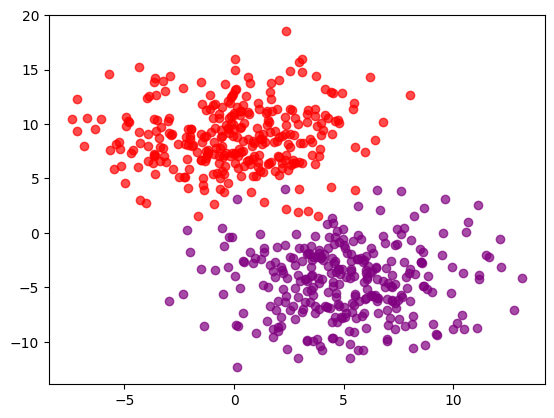

In [9]:
# generate two-class linearly separable synthetic data

import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 23 # try 21, 23, 25, 27

X, y = make_blobs(n_samples=600, n_features=2, centers=2, cluster_std=3, random_state=RANDOM_STATE)

plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', alpha=0.7)
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='purple', alpha=0.7)

plt.show()

In [10]:
# test the classifier with linearly separable synthetic data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, shuffle=True)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

perceptron = Perceptron(total_inputs=2)
perceptron.fit(X_train, y_train, learning_rate=0.1, epochs=100)
predictions = perceptron.predictions(X_test, y_test)
perceptron.evaluate(X_test, y_test, "Classifier for linearly separable synthetic data")

Classifier for linearly separable synthetic data 

[ 1.45087057 -0.81958783] 1
[ 0.14058087 -0.83839713] 1
[0.33861422 0.55214002] 0
[ 0.94229948 -0.82145183] 1
[ 0.65658302 -0.76250211] 1
[0.61352694 1.09641812] 0
[-1.20677354  0.386974  ] 0
[-0.13009704 -0.67582817] 1
[-0.84190449 -0.776997  ] 1
[-0.67685809  1.11799922] 0
[ 1.71329029 -1.06010486] 1
[0.08117744 0.59687658] 0
[ 0.82640229 -1.37934942] 1
[ 0.95536671 -0.89058559] 1
[-1.80837764  0.72305149] 0
[ 0.31718868 -0.99419104] 1
[ 0.80089156 -0.85717889] 1
[ 2.2775061  -0.89570934] 1
[-0.10245343  0.65166974] 0
[1.8763818  0.10752588] 0 is not correct, it must be 1
[ 0.99946088 -0.50139298] 1
[-0.81455572  0.43810433] 0
[ 1.07413636 -1.17081   ] 1
[-0.22965616 -1.41173524] 1
[-0.09202672  0.40553172] 0
[ 0.04525157 -0.61838552] 1
[ 0.55928513 -0.69124694] 1
[-1.15962285  0.98950916] 0
[-0.0220561   0.92854544] 0
[ 1.18874947 -1.66972141] 1
[ 0.24699716 -0.58365891] 1
[0.38169796 0.64617209] 0
[-1.22628488  1.49321419] 0
[-0.43

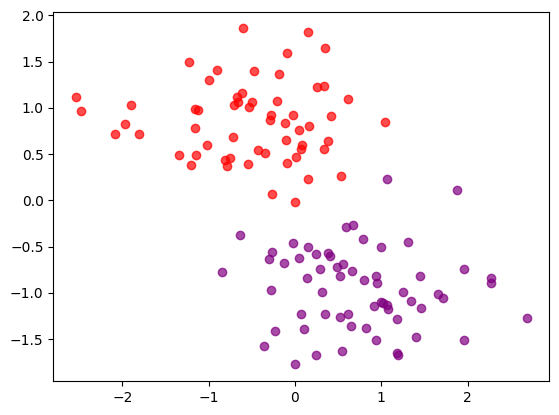

In [11]:
# plot the classifier output

plt.scatter(X_test[y_test == 0][:, 0], X_test[y_test == 0][:, 1], color='red', alpha=0.7)
plt.scatter(X_test[y_test == 1][:, 0], X_test[y_test == 1][:, 1], color='purple', alpha=0.7)

plt.show()